### AI for Power Electronics Control
 * Case study: Adaptive TPS Modulator for DAB with TinyML 
   1. Select from learning curve: Loss/error vs learning capacity
   2. Weight pruning with L1 regularization
   3. Weight quantization
   4. High-performance inference engine: ONNX Runtime

In [1]:
%load_ext autoreload
%autoreload 2

#### 1 Load Optimized Phase Shift Angles for Training

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
df = pd.read_csv("optimization_results.csv")

from sklearn.model_selection import train_test_split

# Define input and output variables
X = df[['Vref', 'P']]
y = df[['D1', 'D2']]

# First, split into train+val and test (e.g., 80% train+val, 20% test)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

# Then, split train+val into train and val (e.g., 75% train, 25% val of trainval, which is 60% train, 20% val overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1, random_state=42
)

# Print the sizes for verification
print(f"Train set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")



Train set size: 40
Validation set size: 5
Test set size: 5


#### 2 Select from Learning Curve: Loss/Error versus Learning Capacity

d:\Anaconda\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Sweeping hidden_size and num_layers...

Training model: hidden_size=4, num_layers=1


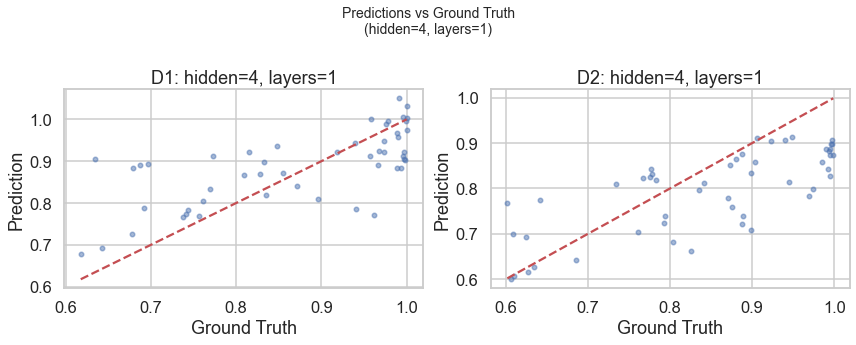


Training model: hidden_size=4, num_layers=2


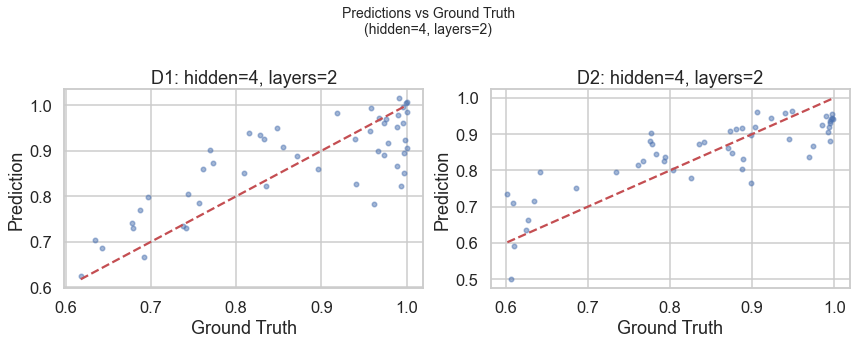


Training model: hidden_size=4, num_layers=3


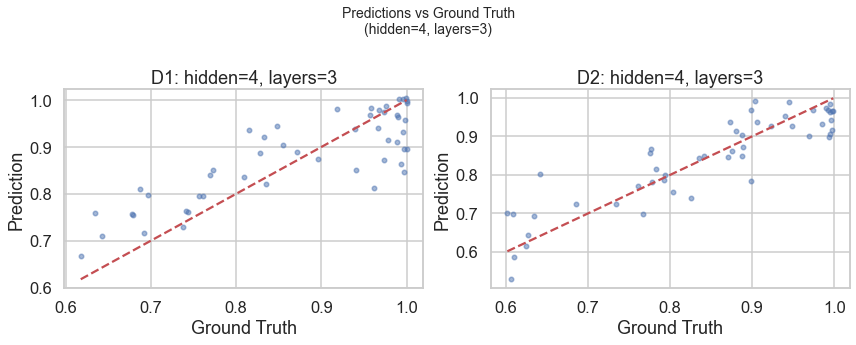


Training model: hidden_size=8, num_layers=1


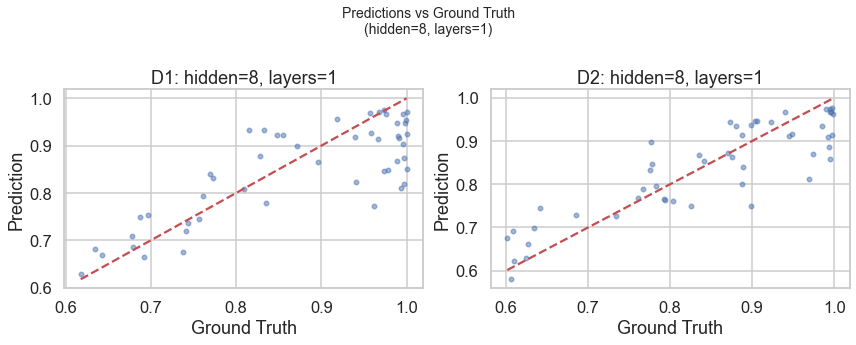


Training model: hidden_size=8, num_layers=2


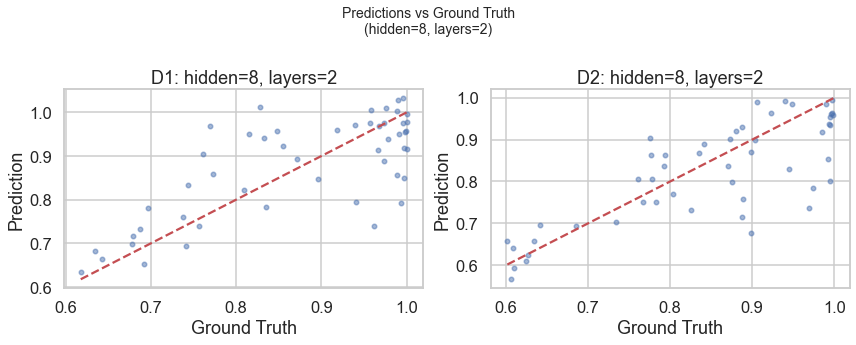


Training model: hidden_size=8, num_layers=3


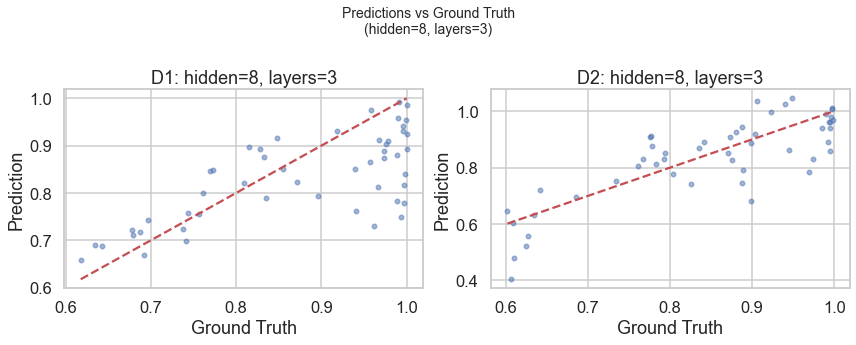


Training model: hidden_size=16, num_layers=1


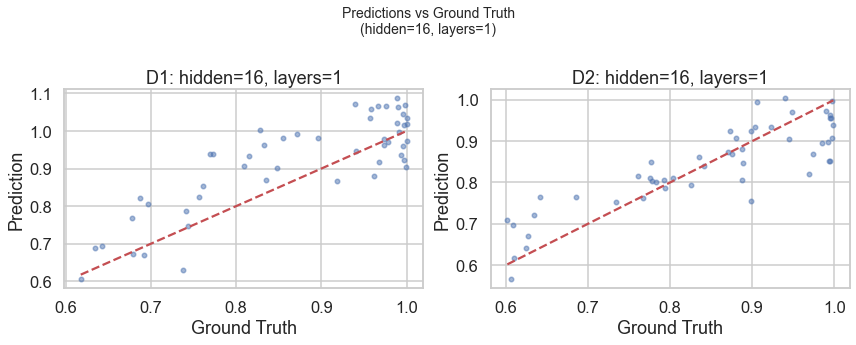


Training model: hidden_size=16, num_layers=2


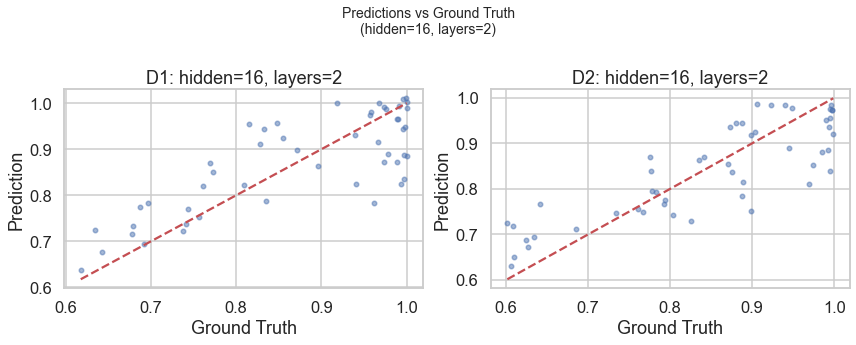


Training model: hidden_size=16, num_layers=3


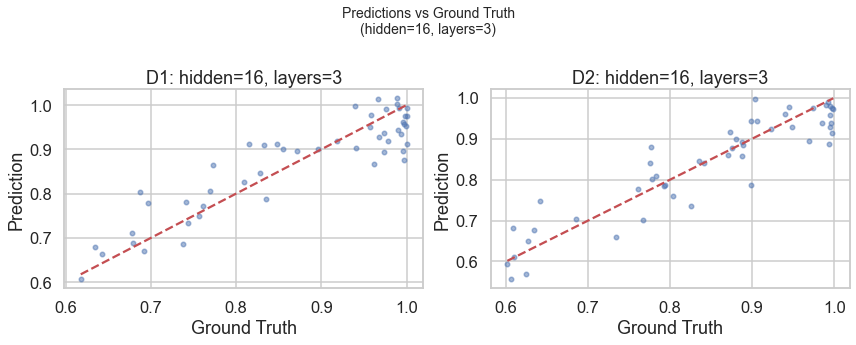


Training model: hidden_size=32, num_layers=1


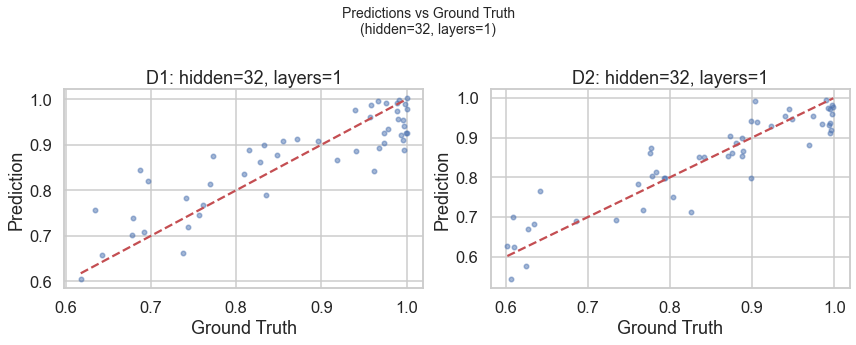


Training model: hidden_size=32, num_layers=2


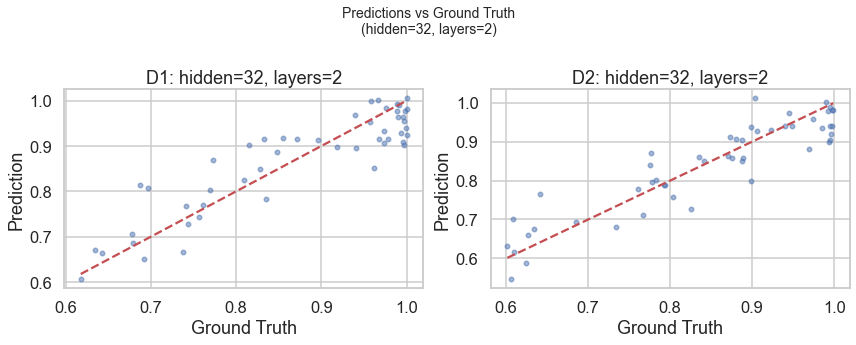


Training model: hidden_size=32, num_layers=3


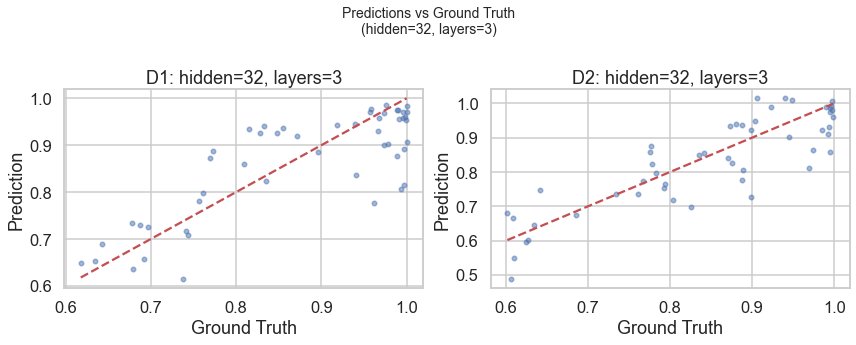


Sweep Results (sorted by all_loss):


,hidden_size,num_layers,all_loss,train_loss,val_loss,test_loss,model_size,best_epoch
8,16,3,0.002665,0.002559,0.002299,0.003883,626,280
10,32,2,0.002764,0.002686,0.002016,0.004139,1218,489
9,32,1,0.003129,0.002847,0.003241,0.005277,162,1000
2,4,3,0.004011,0.003962,0.004105,0.004306,62,1000
3,8,1,0.005067,0.005394,0.002325,0.005197,42,66
11,32,3,0.005250,0.005632,0.001559,0.005878,2274,32
1,4,2,0.005390,0.005584,0.004203,0.005027,42,109
7,16,2,0.005393,0.005443,0.003834,0.006555,354,56
6,16,1,0.005700,0.006064,0.004317,0.004174,82,52
4,8,2,0.007279,0.007819,0.001778,0.008458,114,30


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import numpy as np
import copy
import matplotlib.pyplot as plt
import pandas as pd

# Define the neural network architecture with parameterized hidden size and number of layers
class PhaseShiftMLP(nn.Module):
    def __init__(self, input_size=2, output_size=2, hidden_size=32, num_layers=1):
        super(PhaseShiftMLP, self).__init__()
        layers = []
        in_features = input_size
        for i in range(num_layers):
            layers.append(nn.Linear(in_features, hidden_size))
            # layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.Tanh())
            in_features = hidden_size
        layers.append(nn.Linear(hidden_size, output_size))
        # Use .net attribute for compatibility with compress_mlp_sequential
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        x = self.net(x)
        return x

# Custom dataset class
class PhaseShiftDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
X_all = np.vstack([X_train, X_val, X_test])
X_all_scaled = scaler.transform(X_all)
y_all = np.vstack([y_train.values, y_val.values, y_test.values])

# Prepare datasets and dataloaders
train_dataset = PhaseShiftDataset(X_train_scaled, y_train.values)
val_dataset = PhaseShiftDataset(X_val_scaled, y_val.values)
test_dataset = PhaseShiftDataset(X_test_scaled, y_test.values)

train_loader = DataLoader(train_dataset, batch_size=1000, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1000, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Sweep settings
hidden_sizes = [4, 8, 16, 32]
num_layers_list = [1, 2, 3]

results = []
all_preds = {}

num_epochs = 1000

criterion = nn.MSELoss()

print("Sweeping hidden_size and num_layers...")

for hidden_size in hidden_sizes:
    for num_layers in num_layers_list:
        print(f"\nTraining model: hidden_size={hidden_size}, num_layers={num_layers}")
        model = PhaseShiftMLP(input_size=2, output_size=2, hidden_size=hidden_size, num_layers=num_layers)
        optimizer = optim.Adam(model.parameters(), lr=0.015)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)
        
        train_losses = []
        val_losses = []
        best_val_loss = float('inf')
        best_model_state = None
        best_epoch = -1

        for epoch in range(num_epochs):
            # Training phase
            model.train()
            train_loss = 0.0
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                # Z-score the gradients
                # for param in model.parameters():
                #     if param.grad is not None:
                #         grad_mean = param.grad.mean()
                #         grad_std = param.grad.std()
                #         if grad_std > 0:
                #             param.grad = (param.grad - grad_mean) / grad_std
                optimizer.step()
                train_loss += loss.item()
            scheduler.step()
            
            # Validation phase
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch_X, batch_y in val_loader:
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                    val_loss += loss.item()
            train_losses.append(train_loss / len(train_loader))
            val_losses.append(val_loss / len(val_loader))
            
            # Save best model
            if val_losses[-1] < best_val_loss:
                best_val_loss = val_losses[-1]
                best_model_state = copy.deepcopy(model.state_dict())
                best_epoch = epoch + 1

        # Load the best model (with minimal val loss)
        model.load_state_dict(best_model_state)
        model.eval()
        with torch.no_grad():
            # Evaluate on all data
            all_outputs = model(torch.FloatTensor(X_all_scaled)).numpy()
            all_loss = criterion(torch.FloatTensor(all_outputs), torch.FloatTensor(y_all)).item()
            # Evaluate on train/val/test
            train_outputs = model(torch.FloatTensor(X_train_scaled))
            train_loss_final = criterion(train_outputs, torch.FloatTensor(y_train.values)).item()
            val_outputs = model(torch.FloatTensor(X_val_scaled))
            val_loss_final = criterion(val_outputs, torch.FloatTensor(y_val.values)).item()
            test_outputs = model(torch.FloatTensor(X_test_scaled))
            test_loss_final = criterion(test_outputs, torch.FloatTensor(y_test.values)).item()
        
        # Model size (number of parameters)
        model_size = sum(p.numel() for p in model.parameters())
        
        # Store results
        results.append({
            'hidden_size': hidden_size,
            'num_layers': num_layers,
            'all_loss': all_loss,
            'train_loss': train_loss_final,
            'val_loss': val_loss_final,
            'test_loss': test_loss_final,
            'model_size': model_size,
            'best_epoch': best_epoch
        })
        all_preds[(hidden_size, num_layers)] = (all_outputs, y_all)
        
        # Plot predictions vs ground-truth for D1 and D2
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        axs[0].scatter(y_all[:,0], all_outputs[:,0], alpha=0.5, s=20)
        axs[0].plot([y_all[:,0].min(), y_all[:,0].max()], [y_all[:,0].min(), y_all[:,0].max()], 'r--')
        axs[0].set_title(f'D1: hidden={hidden_size}, layers={num_layers}')
        axs[0].set_xlabel('Ground Truth')
        axs[0].set_ylabel('Prediction')
        axs[0].grid(True)
        axs[1].scatter(y_all[:,1], all_outputs[:,1], alpha=0.5, s=20)
        axs[1].plot([y_all[:,1].min(), y_all[:,1].max()], [y_all[:,1].min(), y_all[:,1].max()], 'r--')
        axs[1].set_title(f'D2: hidden={hidden_size}, layers={num_layers}')
        axs[1].set_xlabel('Ground Truth')
        axs[1].set_ylabel('Prediction')
        axs[1].grid(True)
        plt.suptitle(f'Predictions vs Ground Truth\n(hidden={hidden_size}, layers={num_layers})', fontsize=14)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# Summarize results in a DataFrame
results_df = pd.DataFrame(results)
print("\nSweep Results (sorted by all_loss):")
display(results_df.sort_values('all_loss'))


Pareto-optimal solutions:


,hidden_size,num_layers,all_loss,train_loss,val_loss,test_loss,model_size,best_epoch
0,4,1,0.009104,0.007923,0.013220,0.014430,22,89
3,8,1,0.005067,0.005394,0.002325,0.005197,42,66
2,4,3,0.004011,0.003962,0.004105,0.004306,62,1000
9,32,1,0.003129,0.002847,0.003241,0.005277,162,1000
8,16,3,0.002665,0.002559,0.002299,0.003883,626,280


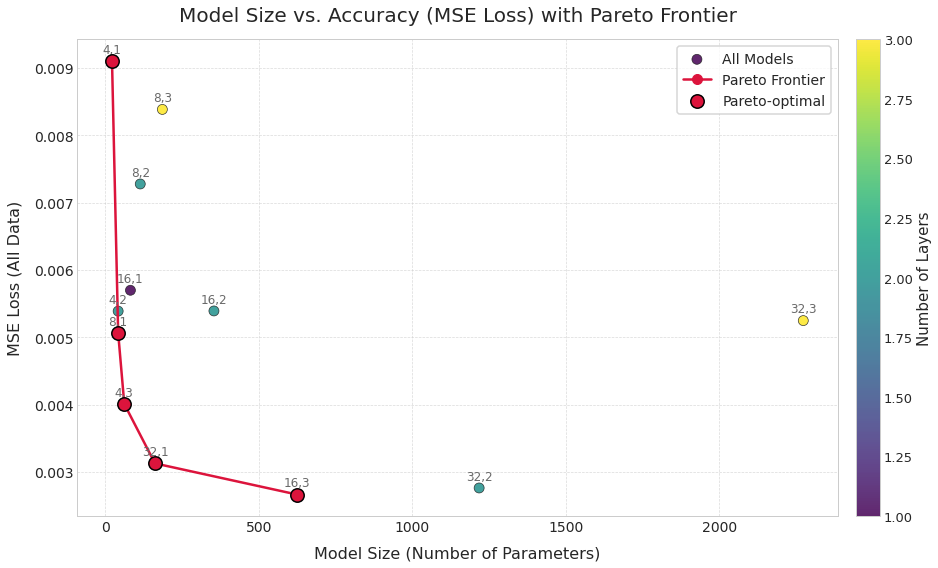

In [6]:
# Professional plot: Model Size vs. Accuracy (MSE Loss) with Pareto Frontier
from paretoset import paretoset
import matplotlib as mpl

# Set professional style
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams.update({
    'axes.titlesize': 20,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 22,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial']
})

fig, ax = plt.subplots(figsize=(14, 8))

# Scatter plot for all models
sc = ax.scatter(
    results_df['model_size'],
    results_df['all_loss'],
    c=results_df['num_layers'],
    cmap='viridis',
    s=100,
    alpha=0.85,
    edgecolor='k',
    linewidth=0.7,
    label='All Models'
)

# Compute Pareto frontier (minimize both model_size and all_loss)
is_pareto = paretoset(results_df[['model_size', 'all_loss']], sense=["min", "min"])
pareto_df = results_df[is_pareto]

# Print the Pareto-optimal solutions
print("Pareto-optimal solutions:")
display(pareto_df.sort_values(['model_size', 'all_loss']))

# Sort Pareto points for plotting the frontier
pareto_sorted = pareto_df.sort_values(['model_size', 'all_loss'])

# Draw Pareto frontier
ax.plot(
    pareto_sorted['model_size'],
    pareto_sorted['all_loss'],
    color='crimson',
    linewidth=2.5,
    linestyle='-',
    marker='o',
    markersize=10,
    label='Pareto Frontier',
    zorder=3
)
ax.scatter(
    pareto_sorted['model_size'],
    pareto_sorted['all_loss'],
    color='crimson',
    s=180,
    edgecolor='black',
    linewidth=1.5,
    marker='o',
    label='Pareto-optimal',
    zorder=4
)

# Annotate each point with hidden_size,num_layers
for _, row in results_df.iterrows():
    ax.annotate(
        f"{int(row['hidden_size'])},{int(row['num_layers'])}",
        (row['model_size'], row['all_loss']),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=12,
        color='dimgray'
    )

# Axis labels and title
ax.set_xlabel('Model Size (Number of Parameters)', labelpad=12)
ax.set_ylabel('MSE Loss (All Data)', labelpad=12)
ax.set_title('Model Size vs. Accuracy (MSE Loss) with Pareto Frontier', pad=18)

# Colorbar for num_layers
cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('Number of Layers', fontsize=15)
cbar.ax.tick_params(labelsize=13)

# Grid, legend, and layout
ax.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)
ax.legend(loc='best', frameon=True, fontsize=14)
plt.tight_layout()
plt.show()

#### 3 Further Accelerate Model Inference with L1 Regularization and Post-Pruning
* Plot the learning curve to determine L1 factor: Loss vs L1 factor

L1 factor: 0.0, Best epoch: 78, Best val loss: 0.001194
L1 factor: 1e-06, Best epoch: 32, Best val loss: 0.001490
L1 factor: 5e-06, Best epoch: 198, Best val loss: 0.002243
L1 factor: 1e-05, Best epoch: 70, Best val loss: 0.001593
L1 factor: 5e-05, Best epoch: 190, Best val loss: 0.001614
L1 factor: 0.0001, Best epoch: 47, Best val loss: 0.001823
L1 factor: 0.0005, Best epoch: 35, Best val loss: 0.002195
L1 factor: 0.001, Best epoch: 34, Best val loss: 0.001592
L1 factor: 0.005, Best epoch: 63, Best val loss: 0.002132
L1 factor: 0.01, Best epoch: 20, Best val loss: 0.015460
L1 factor: 0.05, Best epoch: 92, Best val loss: 0.016070
L1 factor: 0.1, Best epoch: 78, Best val loss: 0.017506

L1 Regularization Sweep Results (sorted by l1_factor):


,l1_factor,all_loss,train_loss,val_loss,test_loss,model_size,best_epoch
0,0.000000,0.004776,0.005220,0.001194,0.004804,62,78
1,0.000001,0.007210,0.007853,0.001490,0.007787,62,32
2,0.000005,0.002834,0.002911,0.002243,0.002809,62,198
3,0.000010,0.005113,0.005620,0.001593,0.004573,62,70
4,0.000050,0.002622,0.002606,0.001614,0.003757,62,190
5,0.000100,0.007753,0.008315,0.001823,0.009185,62,47
6,0.000500,0.007847,0.008557,0.002195,0.007820,62,35
7,0.001000,0.007529,0.008226,0.001592,0.007889,62,34
8,0.005000,0.008782,0.009534,0.002132,0.009421,62,63
9,0.010000,0.023448,0.023998,0.015460,0.027038,62,20


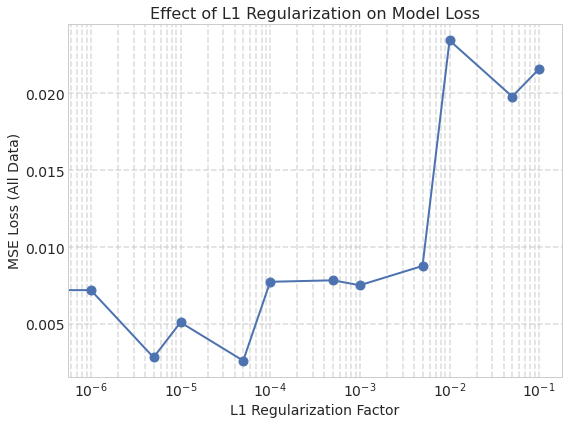

In [7]:
# Sweep L1 regularization factor for 1 layer, 8 neurons

l1_factors = [0.0, 1e-6, 5e-6, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1]
l1_results = []

num_epochs_l1 = 500  # Fewer epochs since structure is fixed

for l1_factor in l1_factors:
    model = PhaseShiftMLP(input_size=2, output_size=2, hidden_size=4, num_layers=3)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)
    criterion = nn.MSELoss()
    
    best_val_loss = float('inf')
    best_model_state = None
    best_epoch = -1

    for epoch in range(num_epochs_l1):
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            mse_loss = criterion(outputs, batch_y)
            l1_loss = 0.0
            for param in model.parameters():
                l1_loss += torch.sum(torch.abs(param))
            loss = mse_loss + l1_factor * l1_loss
            loss.backward()
            # Z-score the gradients
            for param in model.parameters():
                if param.grad is not None:
                    grad_mean = param.grad.mean()
                    grad_std = param.grad.std()
                    if grad_std > 0:
                        param.grad = (param.grad - grad_mean) / grad_std
            optimizer.step()
            train_loss += loss.item()
        scheduler.step()
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X)
                mse_loss = criterion(outputs, batch_y)
                l1_loss = 0.0
                for param in model.parameters():
                    l1_loss += torch.sum(torch.abs(param))
                loss = mse_loss + l1_factor * l1_loss
                val_loss += mse_loss.item()
        avg_val_loss = val_loss / len(val_loader)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

    # Evaluate best model
    model.load_state_dict(best_model_state)
    model.eval()
    with torch.no_grad():
        all_outputs = model(torch.FloatTensor(X_all_scaled)).numpy()
        all_loss = criterion(torch.FloatTensor(all_outputs), torch.FloatTensor(y_all)).item()
        train_outputs = model(torch.FloatTensor(X_train_scaled))
        train_loss_final = criterion(train_outputs, torch.FloatTensor(y_train.values)).item()
        val_outputs = model(torch.FloatTensor(X_val_scaled))
        val_loss_final = criterion(val_outputs, torch.FloatTensor(y_val.values)).item()
        test_outputs = model(torch.FloatTensor(X_test_scaled))
        test_loss_final = criterion(test_outputs, torch.FloatTensor(y_test.values)).item()
    model_size = sum(p.numel() for p in model.parameters())
    l1_results.append({
        'l1_factor': l1_factor,
        'all_loss': all_loss,
        'train_loss': train_loss_final,
        'val_loss': val_loss_final,
        'test_loss': test_loss_final,
        'model_size': model_size,
        'best_epoch': best_epoch
    })
    print(f"L1 factor: {l1_factor}, Best epoch: {best_epoch}, Best val loss: {best_val_loss:.6f}")

# Convert to DataFrame and plot
l1_results_df = pd.DataFrame(l1_results)
print("\nL1 Regularization Sweep Results (sorted by l1_factor):")
display(l1_results_df.sort_values('l1_factor'))

plt.figure(figsize=(8,6))
plt.plot(l1_results_df['l1_factor'], l1_results_df['all_loss'], marker='o', linewidth=2)
plt.xscale('log')
plt.xlabel('L1 Regularization Factor', fontsize=14)
plt.ylabel('MSE Loss (All Data)', fontsize=14)
plt.title('Effect of L1 Regularization on Model Loss', fontsize=16)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [8]:
# Train a model with L1 factor = 0.001, then prune small weights
# Compare the speed of the NN before and after pruning

import torch
import time

torch.manual_seed(42)

l1_factor = 5e-3
hidden_size = 4
num_layers = 3
num_epochs = 500

# Train the model
model = PhaseShiftMLP(input_size=2, output_size=2, hidden_size=hidden_size, num_layers=num_layers)
model = torch.jit.script(model)
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)
criterion = nn.MSELoss()

best_val_loss = float('inf')
best_model_state = None
best_epoch = -1

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        mse_loss = criterion(outputs, batch_y)
        l1_loss = 0.0
        for param in model.parameters():
            l1_loss += torch.sum(torch.abs(param))
        loss = mse_loss + l1_factor * l1_loss
        loss.backward()
        # Z-score the gradients
        for param in model.parameters():
            if param.grad is not None:
                grad_mean = param.grad.mean()
                grad_std = param.grad.std()
                if grad_std > 0:
                    param.grad = (param.grad - grad_mean) / grad_std
        optimizer.step()
        train_loss += loss.item()
    scheduler.step()
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            mse_loss = criterion(outputs, batch_y)
            l1_loss = 0.0
            for param in model.parameters():
                l1_loss += torch.sum(torch.abs(param))
            loss = mse_loss + l1_factor * l1_loss
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1

# Load best model
model.load_state_dict(best_model_state)
model.eval()

# Count weights close to zero (threshold = 1e-3)
zero_threshold = 1e-3
total_weights = 0
zero_weights = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        num_total = param.numel()
        num_zero = (param.abs() < zero_threshold).sum().item()
        print(f"{name}: {num_zero}/{num_total} weights close to 0 (|w| < {zero_threshold})")
        total_weights += num_total
        zero_weights += num_zero
print(f"Total: {zero_weights}/{total_weights} weights close to 0 ({100*zero_weights/total_weights:.2f}%)")

# --- Speed test before pruning ---
def measure_inference_time(model, X, n_runs=5000):
    model.eval()
    X_tensor = torch.FloatTensor(X)
    # Warm-up
    with torch.no_grad():
        _ = model(X_tensor)
    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(n_runs):
            _ = model(X_tensor)
    end = time.perf_counter()
    avg_time = (end - start) / n_runs
    return avg_time

inference_time_before = measure_inference_time(model, X_test_scaled, n_runs=5000)
print(f"\nAverage inference time BEFORE pruning: {inference_time_before*1e3:.4f} ms per run (on {len(X_test_scaled)} samples)")

# Prune weights: set small weights to exactly zero
with torch.no_grad():
    for param in model.parameters():
        mask = param.abs() < zero_threshold
        param[mask] = 0.0

# Evaluate pruned model
with torch.no_grad():
    all_outputs = model(torch.FloatTensor(X_all_scaled)).numpy()
    all_loss = criterion(torch.FloatTensor(all_outputs), torch.FloatTensor(y_all)).item()
    train_outputs = model(torch.FloatTensor(X_train_scaled))
    train_loss_final = criterion(train_outputs, torch.FloatTensor(y_train.values)).item()
    val_outputs = model(torch.FloatTensor(X_val_scaled))
    val_loss_final = criterion(val_outputs, torch.FloatTensor(y_val.values)).item()
    test_outputs = model(torch.FloatTensor(X_test_scaled))
    test_loss_final = criterion(test_outputs, torch.FloatTensor(y_test.values)).item()

print("\nAfter pruning:")
print(f"All loss:   {all_loss:.6f}")
print(f"Train loss: {train_loss_final:.6f}")
print(f"Val loss:   {val_loss_final:.6f}")
print(f"Test loss:  {test_loss_final:.6f}")

# Optionally, print model size after pruning (number of nonzero weights)
nonzero_weights = 0
for param in model.parameters():
    nonzero_weights += (param.abs() > 0).sum().item()
print(f"Nonzero weights after pruning: {nonzero_weights}/{total_weights} ({100*nonzero_weights/total_weights:.2f}%)")

# --- Speed test after pruning ---
inference_time_after = measure_inference_time(model, X_test_scaled, n_runs=100)
print(f"\nAverage inference time AFTER pruning: {inference_time_after*1e3:.4f} ms per run (on {len(X_test_scaled)} samples)")

speedup = inference_time_before / inference_time_after if inference_time_after > 0 else float('inf')
print(f"\nSpeedup (before/after): {speedup:.2f}x")

net.0.weight: 1/8 weights close to 0 (|w| < 0.001)
net.0.bias: 2/4 weights close to 0 (|w| < 0.001)
net.2.weight: 14/16 weights close to 0 (|w| < 0.001)
net.2.bias: 1/4 weights close to 0 (|w| < 0.001)
net.4.weight: 8/16 weights close to 0 (|w| < 0.001)
net.4.bias: 0/4 weights close to 0 (|w| < 0.001)
net.6.weight: 4/8 weights close to 0 (|w| < 0.001)
net.6.bias: 0/2 weights close to 0 (|w| < 0.001)
Total: 30/62 weights close to 0 (48.39%)

Average inference time BEFORE pruning: 0.0701 ms per run (on 5 samples)

After pruning:
All loss:   0.009224
Train loss: 0.009827
Val loss:   0.003764
Test loss:  0.009856
Nonzero weights after pruning: 32/62 (51.61%)

Average inference time AFTER pruning: 0.0603 ms per run (on 5 samples)

Speedup (before/after): 1.16x


#### 4 Weight Quantization and ONNX Runtime Optimization

In [9]:
import onnx
import onnxruntime
import torch.onnx

# Export the trained (and pruned) PyTorch model to ONNX
onnx_model_path = "phase_shift_mlp.onnx"
dummy_input = torch.FloatTensor(X_test_scaled)
torch.onnx.export(
    model,
    dummy_input,
    onnx_model_path,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    opset_version=12
)
print(f"Model exported to {onnx_model_path}")

# Load the ONNX model
onnx_model = onnx.load(onnx_model_path)

# --- Inference with ONNX Runtime (with acceleration) ---
import numpy as np

# Try to use the fastest available execution provider
available_providers = onnxruntime.get_available_providers()
preferred_providers = []
if 'CUDAExecutionProvider' in available_providers:
    preferred_providers.append('CUDAExecutionProvider')
if 'OpenVINOExecutionProvider' in available_providers:
    preferred_providers.append('OpenVINOExecutionProvider')
if 'TensorrtExecutionProvider' in available_providers:
    preferred_providers.append('TensorrtExecutionProvider')
if 'CoreMLExecutionProvider' in available_providers:
    preferred_providers.append('CoreMLExecutionProvider')
# Always fall back to CPU if nothing else
preferred_providers.append('CPUExecutionProvider')

print("Available ONNX Runtime providers:", available_providers)
print("Using ONNX Runtime providers (in order):", preferred_providers)

# For compatibility with the PA-RNN code, use the same session creation logic
ort_session = onnxruntime.InferenceSession(onnx_model_path, providers=preferred_providers)

def onnx_inference(ort_session, X):
    # X: numpy array
    ort_inputs = {ort_session.get_inputs()[0].name: X.astype(np.float32)}
    ort_outs = ort_session.run(None, ort_inputs)
    return ort_outs[0]

# Try to enable graph optimizations and IO binding for further speedup
def measure_onnx_inference_time(ort_session, X, n_runs=1000):
    # Warm-up
    _ = onnx_inference(ort_session, X)
    # Try IO binding if available (for GPU)
    try:
        io_binding = ort_session.io_binding()
        input_name = ort_session.get_inputs()[0].name
        # Determine device type and id
        provider = ort_session.get_providers()[0]
        if provider == "CPUExecutionProvider":
            device_type = "cpu"
            device_id = 0
        elif provider == "CUDAExecutionProvider":
            device_type = "cuda"
            device_id = 0
        elif provider == "OpenVINOExecutionProvider":
            device_type = "cpu"  # OpenVINO usually runs on CPU
            device_id = 0
        elif provider == "TensorrtExecutionProvider":
            device_type = "cuda"
            device_id = 0
        elif provider == "CoreMLExecutionProvider":
            device_type = "cpu"  # CoreML runs on Apple devices
            device_id = 0
        else:
            device_type = "cpu"
            device_id = 0
        io_binding.bind_input(
            name=input_name,
            device_type=device_type,
            device_id=device_id,
            element_type=np.float32,
            shape=X.shape,
            buffer_ptr=X.astype(np.float32).ctypes.data
        )
        output_name = ort_session.get_outputs()[0].name
        io_binding.bind_output(output_name)
        import time
        start = time.perf_counter()
        for _ in range(n_runs):
            ort_session.run_with_iobinding(io_binding)
        end = time.perf_counter()
        avg_time = (end - start) / n_runs
        return avg_time
    except Exception as e:
        # Fallback to normal inference
        import time
        start = time.perf_counter()
        for _ in range(n_runs):
            _ = onnx_inference(ort_session, X)
        end = time.perf_counter()
        avg_time = (end - start) / n_runs
        return avg_time

onnx_inference_time = measure_onnx_inference_time(ort_session, X_test_scaled, n_runs=1000)
print(f"\nAverage inference time with ONNX model: {onnx_inference_time*1e3:.4f} ms per run (on {len(X_test_scaled)} samples)")

# Compare with PyTorch model inference time after pruning
print(f"Average inference time with PyTorch model after pruning: {inference_time_after*1e3:.4f} ms per run (on {len(X_test_scaled)} samples)")
if onnx_inference_time > 0:
    onnx_speedup = inference_time_after / onnx_inference_time
else:
    onnx_speedup = float('inf')
print(f"Speedup (PyTorch pruned time / ONNX time): {onnx_speedup:.2f}x")

# Evaluate ONNX model accuracy
onnx_outputs = onnx_inference(ort_session, X_test_scaled)
onnx_test_loss = criterion(torch.FloatTensor(onnx_outputs), torch.FloatTensor(y_test.values)).item()
print(f"Test loss (ONNX): {onnx_test_loss:.6f}")

# Compare model file size
import os
orig_size = os.path.getsize(onnx_model_path) / 1024
print(f"ONNX model size: {orig_size:.1f} KB")


Model exported to phase_shift_mlp.onnx
Available ONNX Runtime providers: ['AzureExecutionProvider', 'CPUExecutionProvider']
Using ONNX Runtime providers (in order): ['CPUExecutionProvider']

Average inference time with ONNX model: 0.0109 ms per run (on 5 samples)
Average inference time with PyTorch model after pruning: 0.0603 ms per run (on 5 samples)
Speedup (PyTorch pruned time / ONNX time): 5.55x
Test loss (ONNX): 0.009856
ONNX model size: 1.2 KB


In [10]:
# Quantize the ONNX model to use 8-bit integer weights for further acceleration
from onnxruntime.quantization import quantize_dynamic, QuantType

quantized_onnx_model_path = "phase_shift_mlp_quantized.onnx"
quantize_dynamic(
    onnx_model_path,
    quantized_onnx_model_path,
    weight_type=QuantType.QInt8
)
print(f"Quantized ONNX model saved to {quantized_onnx_model_path}")

# Load quantized model and measure inference time
ort_session_quant = onnxruntime.InferenceSession(quantized_onnx_model_path, providers=preferred_providers)
onnx_quant_inference_time = measure_onnx_inference_time(ort_session_quant, X_test_scaled, n_runs=1000)
print(f"\nAverage inference time with quantized ONNX model: {onnx_quant_inference_time*1e3:.4f} ms per run (on {len(X_test_scaled)} samples)")

# Compare model file size
quant_size = os.path.getsize(quantized_onnx_model_path) / 1024
print(f"Quantized ONNX model size: {quant_size:.1f} KB")
if onnx_quant_inference_time > 0:
    quant_speedup = inference_time_after / onnx_quant_inference_time
else:
    quant_speedup = float('inf')
print(f"Speedup (PyTorch pruned time / Quantized ONNX time): {quant_speedup:.2f}x")

# Evaluate quantized ONNX model accuracy on test set
onnx_quant_outputs = onnx_inference(ort_session_quant, X_test_scaled)
onnx_quant_test_loss = criterion(torch.FloatTensor(onnx_quant_outputs), torch.FloatTensor(y_test.values)).item()
print(f"Test loss (Quantized ONNX, test set): {onnx_quant_test_loss:.6f}")

# Validate quantized model accuracy on train and validation sets as well
onnx_quant_train_outputs = onnx_inference(ort_session_quant, X_train_scaled)
onnx_quant_train_loss = criterion(torch.FloatTensor(onnx_quant_train_outputs), torch.FloatTensor(y_train.values)).item()
print(f"Train loss (Quantized ONNX): {onnx_quant_train_loss:.6f}")

onnx_quant_val_outputs = onnx_inference(ort_session_quant, X_val_scaled)
onnx_quant_val_loss = criterion(torch.FloatTensor(onnx_quant_val_outputs), torch.FloatTensor(y_val.values)).item()
print(f"Validation loss (Quantized ONNX): {onnx_quant_val_loss:.6f}")

# Optionally, check all data loss
onnx_quant_all_outputs = onnx_inference(ort_session_quant, X_all_scaled)
onnx_quant_all_loss = criterion(torch.FloatTensor(onnx_quant_all_outputs), torch.FloatTensor(y_all)).item()
print(f"All data loss (Quantized ONNX): {onnx_quant_all_loss:.6f}")


Quantized ONNX model saved to phase_shift_mlp_quantized.onnx

Average inference time with quantized ONNX model: 0.0214 ms per run (on 5 samples)
Quantized ONNX model size: 4.7 KB
Speedup (PyTorch pruned time / Quantized ONNX time): 2.81x
Test loss (Quantized ONNX, test set): 0.009865
Train loss (Quantized ONNX): 0.009849
Validation loss (Quantized ONNX): 0.003872
All data loss (Quantized ONNX): 0.009253
